In [2]:
%env CUDA_VISIBLE_DEVICES=7

env: CUDA_VISIBLE_DEVICES=7


In [3]:
import sys
import torch
sys.path.append('/home/gaoya/code_my_utils')
from tools.pil import grid_pil,text_pil
from tools.seed import seed_everything
seed_everything(42)
device = torch.device("cuda")


# Simulation


In [4]:
import sys
sys.path.append('/home/gaoya/code_my_utils')
from tools.pil import grid_pil,text_pil
from tools.seed import seed_everything
from PIL import Image
from omegaconf import OmegaConf
input_image_path = "/home/gaoya/Code_Video/demo_my/assets/lamp.png"
inpainted_image_path = "/home/gaoya/Code_Video/demo_my/assets/lamp_inpainted.png"
input_image_pil = Image.open(input_image_path).convert('RGB')
config_path = "/home/gaoya/Code_Video/RealWonder-main/demo_web/demo_data/lamp/config.yaml"
config = OmegaConf.load(config_path)

### sam 获取 object_masks


In [5]:
import sys
import matplotlib.pyplot as plt
import numpy as np

sys.path.append('/home/gaoya/Code_Video/RealWonder-main')
sys.path.append("/home/gaoya/Grounded-SAM-2-main")
from simulation.image23D.segmenter import SegmentAnythingSegmenter,show_points,show_masks
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2ImagePredictor
image = np.array(input_image_pil)
SAM2_CHECKPOINT = "/data/gaoya/ckpt/facebook-sam2.1-hiera-large/sam2.1_hiera_large.pt"


SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
sam2_model = build_sam2(SAM2_CONFIG, SAM2_CHECKPOINT, device=device)
predictor = SAM2ImagePredictor(sam2_model)
predictor.set_image(image)


/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


In [6]:
# all_object_points = config['all_object_points']
# all_object_masks_idx = config['all_object_masks_idx']

# 两个物体
all_object_points=[
    [
        [0, 10, 1], [10, 0, 1]
        ],
    [
        [250, 207, 1], [273, 287, 1]
        ]
    ]
all_object_masks_idx = [1,1]
# # 单个物体

# all_object_points=[
#     [
#         [250, 207, 1], [273, 287, 1]
#         ]
#     ]
# all_object_masks_idx = [1]

/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Memory efficient kernel not used because: (Triggered internally at ../aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:773.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at ../aten/src/ATen/native/transformers/sdp_utils_cpp.h:558.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Flash attention kernel not used because: (Triggered internally at ../aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:775.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py31

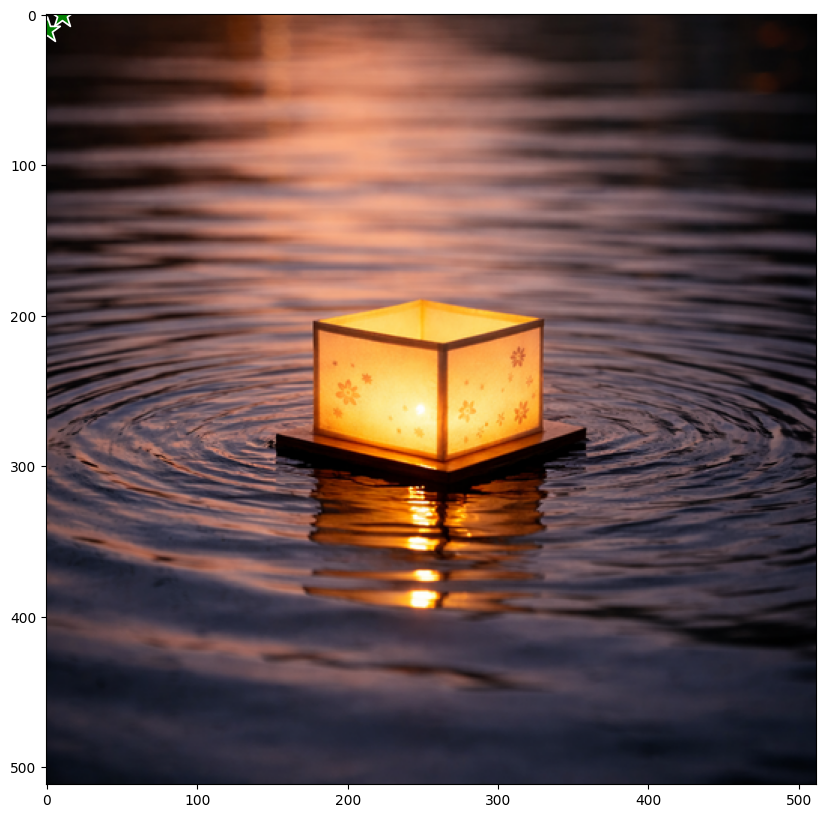

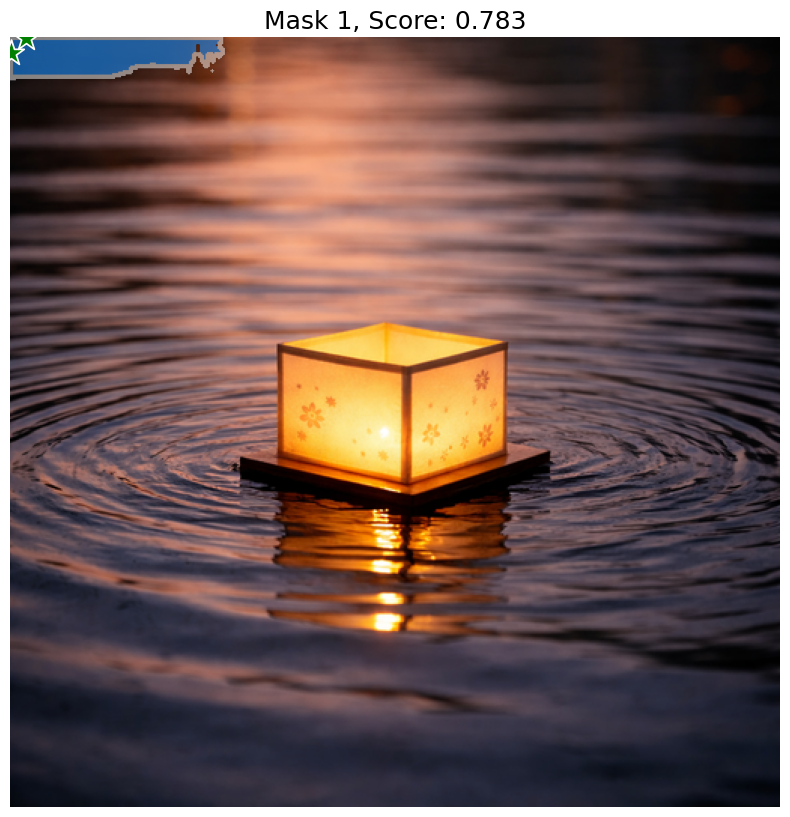

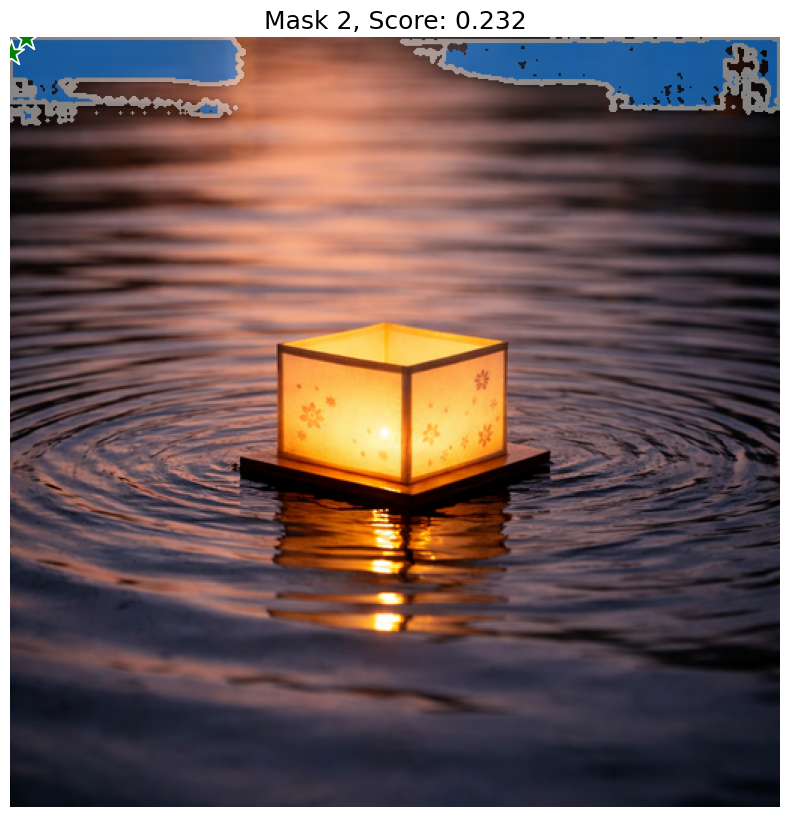

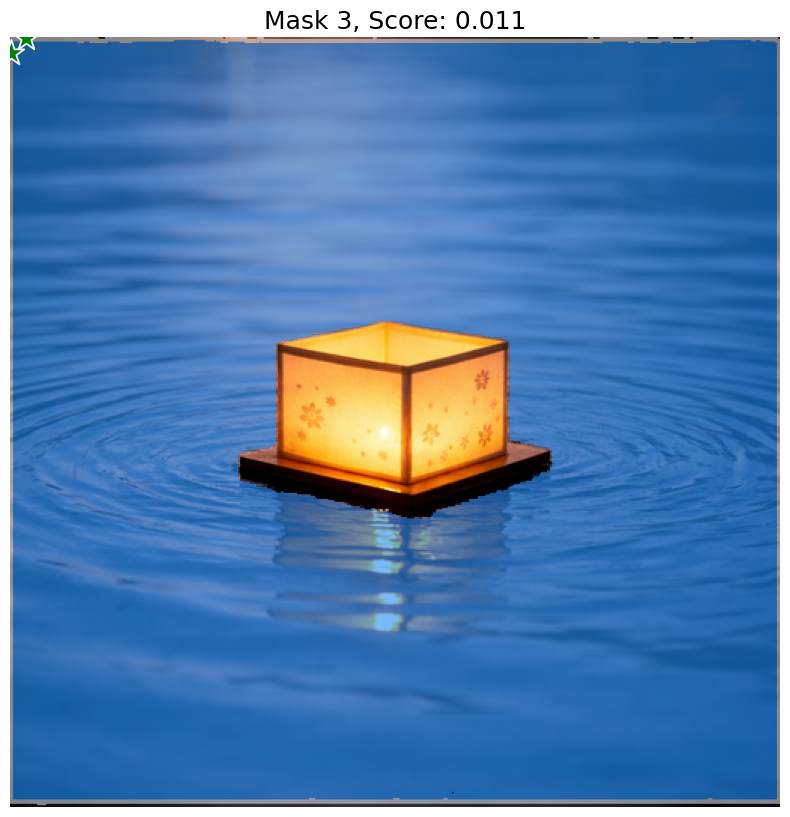

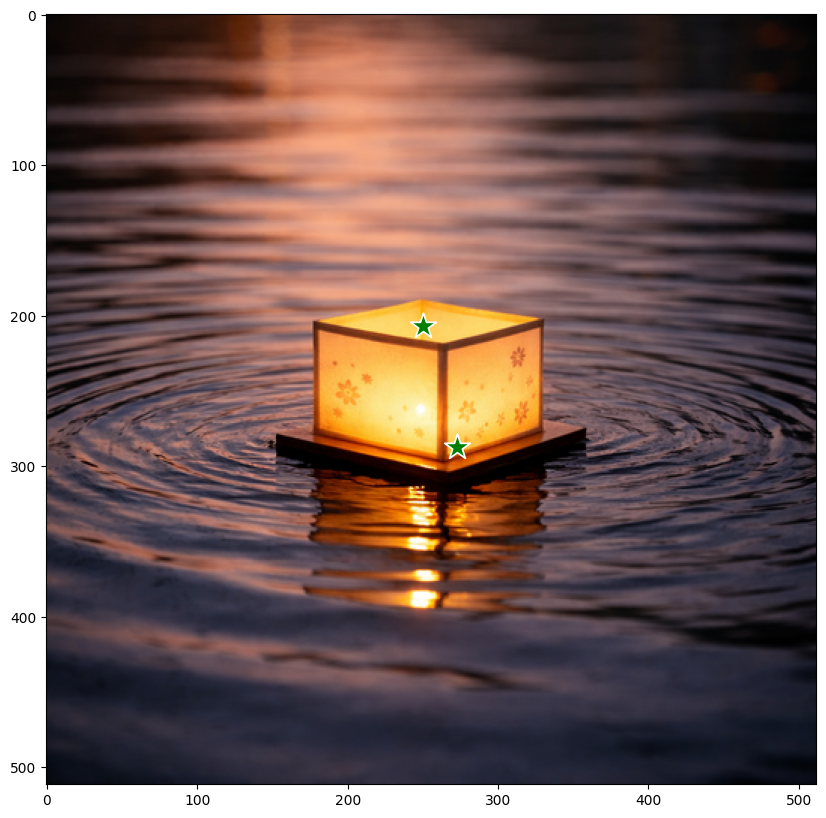

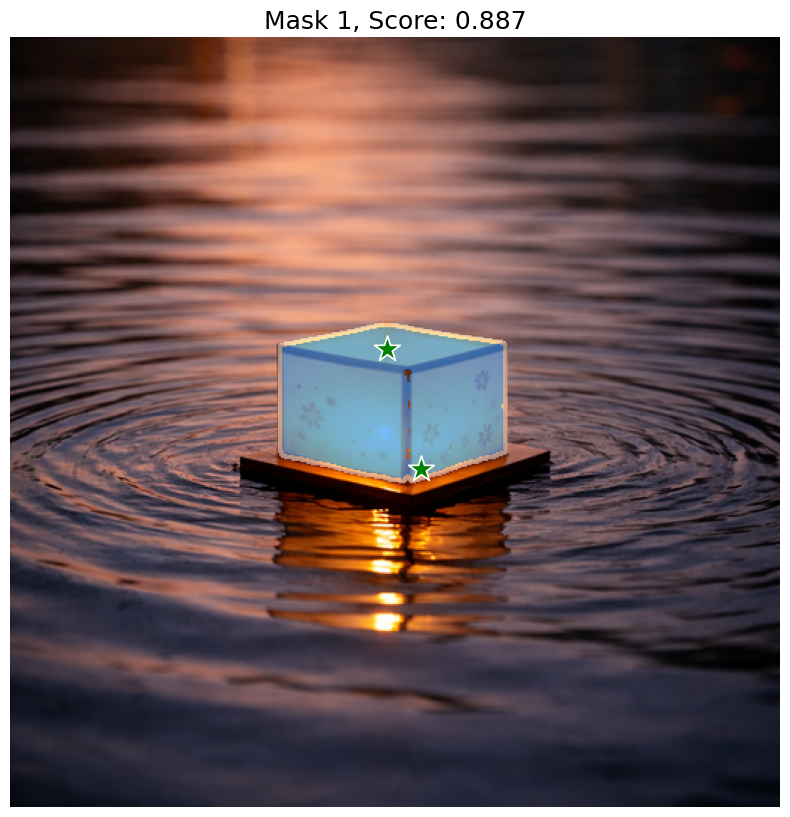

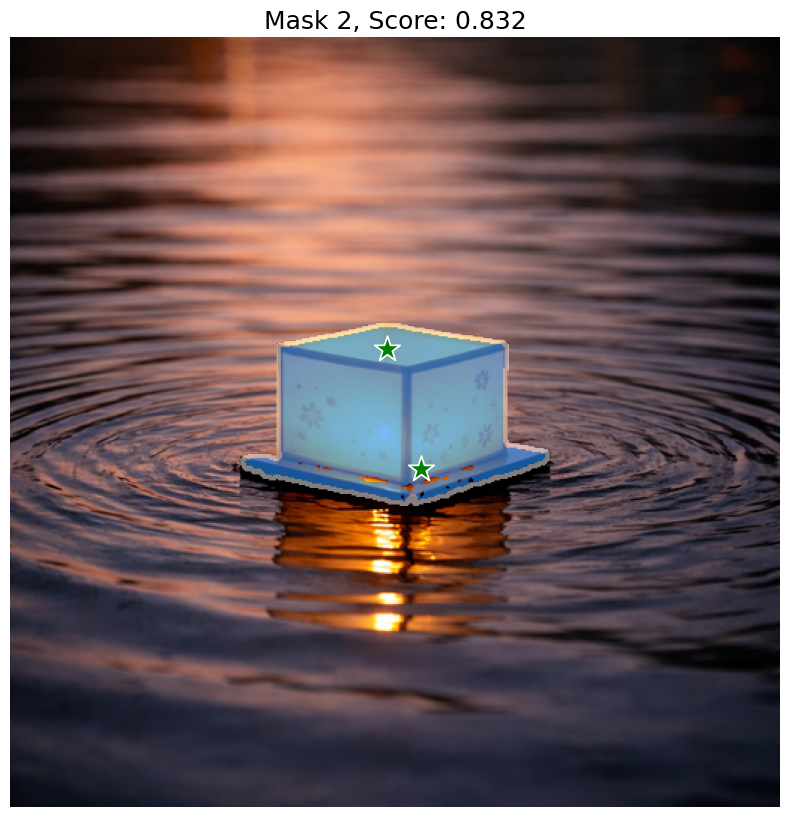

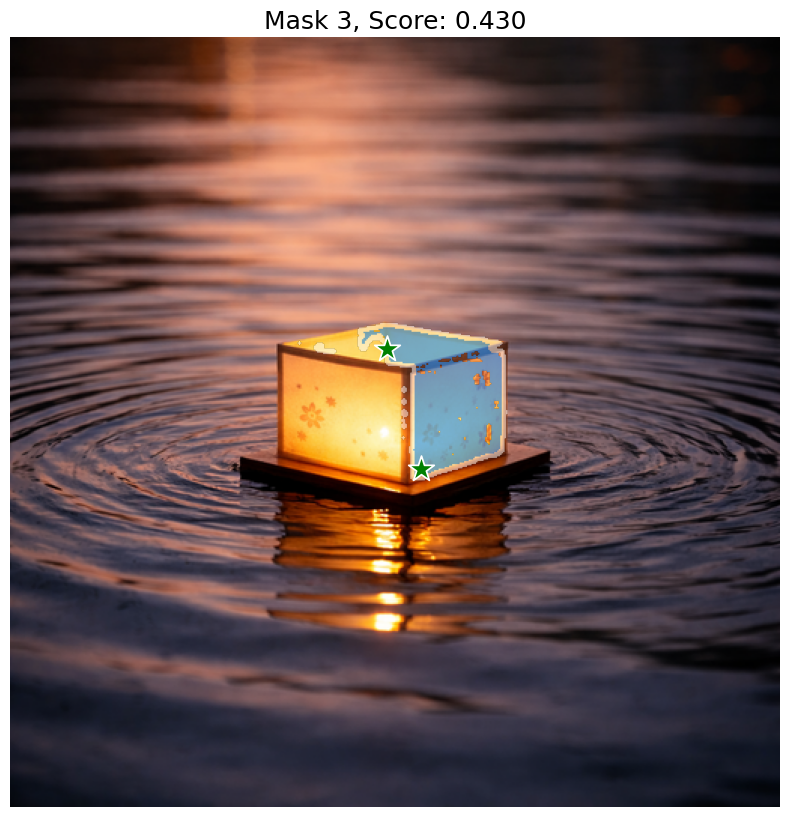

In [7]:

target_masks = []
for object_idx, object_points in enumerate(all_object_points):
    
    '''
    # for each object 
    每次循环（每个object_idx）处理一个物体
    从all_object_points中提取当前物体的点坐标和标签（一个物体可能包含多个点坐标 object_points）
    '''
    
    object_points = np.array(object_points)
    object_points_xy = object_points[:, :2].copy()
    object_point_labels = object_points[:, 2].copy()

    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_points(object_points_xy, object_point_labels, plt.gca())

    plt.axis('on')
    plt.savefig(f"/home/gaoya/Code_Video/RealWonder-main/debug_my/sam2/input_points_{object_idx:02d}.png")

    masks, scores, logits = predictor.predict(
        point_coords=object_points_xy,
        point_labels=object_point_labels,
        multimask_output=True,
    )
    sorted_ind = np.argsort(scores)[::-1]# 把scores大的排在前面
    masks = masks[sorted_ind]
    scores = scores[sorted_ind]
    logits = logits[sorted_ind]

    show_masks(image, masks, scores, f"object_{object_idx:02d}", point_coords=object_points_xy, input_labels=object_point_labels, borders=True)
    target_masks.append(masks[all_object_masks_idx[object_idx]])# 选择第all_object_masks_idx[object_idx]个mask，按照config来是3个中的第2个
# display(Image.fromarray(np.uint8(target_masks[0]*255)))
object_masks = [torch.from_numpy(mask).to(device) for mask in target_masks]    


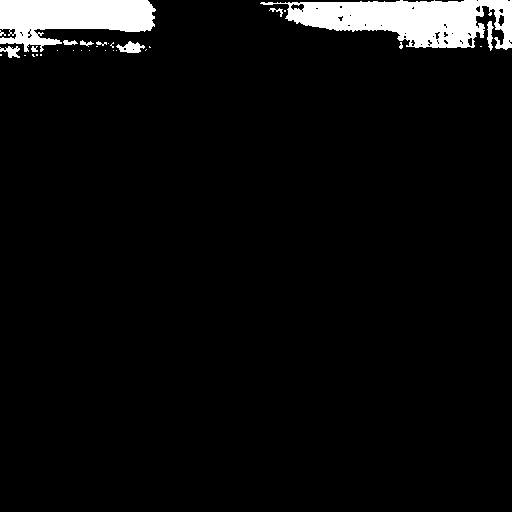

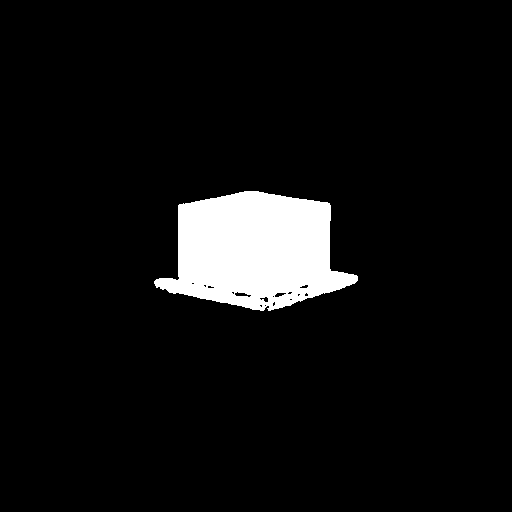

In [8]:
for i in range(len(object_masks)):      
    
    display(Image.fromarray(np.uint8(object_masks[i].cpu()*255)))

### inpaint

In [9]:
from torchvision.transforms import ToTensor
'''

all_objects_masks = torch.zeros_like(object_masks[0], dtype=torch.bool)
for mask in object_masks:
    all_objects_masks = all_objects_masks | mask.bool()
'''
# 获取扣除所有前景物体后的背景pil，如果没有背景图就用inpainter
inpainted_image = ToTensor()(Image.open(inpainted_image_path).convert('RGB')).to(device)


### 前景mask → 3D mesh & 点云

1. mesh 适合
    - 放进 Genesis 做仿真
    - 做刚体/碰撞
    - 表面是连续的
2. 点云适合
    - 按仿真结果快速更新表面位置
    - 重新喂给渲染器
    - 更新位置比较方便

#### mesh生成

In [10]:
from simulation.image23D.mesh_generator import Sam3DMeshGenerator
mesh_generator = Sam3DMeshGenerator(config)

2026-03-12 02:36:59.831 | INFO     | sam3d_objects.pipeline.inference_pipeline:set_attention_backend:17 - GPU name is NVIDIA GeForce RTX 4090


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-12 02:37:00.993 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.sparse:__from_env:39 - [SPARSE] Backend: spconv, Attention: sdpa
2026-03-12 02:37:05.934 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-12 02:37:06.731 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-12 02:37:06.733 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-12 02:37:06.790 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
/home/gaoya/Code_Video/MoGe-main/moge/model/v1.py:178: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")
2026-03-12 02:37:11.426 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-12 02:37:11.429 | INFO     | sam3d_objects.pipeline.inference_pipeline:__init__:100 - self.dev

In [11]:
fg_meshes = []
fg_pcs = []
'''
对图像中被 mask 指定出来的那个物体做 3D 重建。
mesh_resize_factor:
    对最终 mesh 的尺度做缩放,默认是 1.0
    如果设成 2.0，mesh 会放大 2 倍
    如果设成 0.5，mesh 会缩小一半
target_faces:
    希望简化后的 mesh 面数大概是多少
'''
per_mask = object_masks[-1]
original_mesh, simplified_mesh, fx_pixels, fx_deg, _ = mesh_generator(np.array(input_image_pil), per_mask.cpu().numpy(), mesh_resize_factor=config['mesh_resize_factor'], target_faces=config['target_faces'])
'''
original_mesh：原始 mesh（trimesh）
simplified_mesh：简化/填孔后的 mesh（trimesh）
fx_pixels：焦距（像素）
fov_x_deg：水平视场角（度）
fov_x_rad：水平视场角（弧度）

'''

2026-03-12 02:37:27.170 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:664 - Sampling sparse structure: inference_steps=25, strength=7, interval=[0, 500], rescale_t=3, cfg_strength_pm=0.0
2026-03-12 02:37:27.171 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-12 02:37:27.240 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!


2026-03-12 02:37:30.987 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_sparse_structure:714 - Downsampled coords from 30202 to 29830
2026-03-12 02:37:31.004 | INFO     | sam3d_objects.pipeline.inference_pipeline_pointmap:run:437 - Rescaling scale by 1 after downsampling
2026-03-12 02:37:31.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:sample_slat:744 - Sampling sparse latent: inference_steps=25, strength=1, interval=[0, 500], rescale_t=1
2026-03-12 02:37:31.005 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:633 - Running condition embedder ...
2026-03-12 02:37:31.047 | INFO     | sam3d_objects.pipeline.inference_pipeline:get_condition_input:637 - Condition embedder finishes!
2026-03-12 02:37:36.541 | INFO     | sam3d_objects.pipeline.inference_pipeline:decode_slat:606 - Decoding sparse latent...
2026-03-12 02:37:46.581 | INFO     | sam3d_objects.pipeline.inference_pipeline:postprocess_slat_output:540 - Postprocessing mesh with opt

[mesh_generator] intrinsics is None, fallback to default FOV=60 deg
mesh is not watertight, filling holes...
-0.195 1.785


'\noriginal_mesh：原始 mesh（trimesh）\nsimplified_mesh：简化/填孔后的 mesh（trimesh）\nfx_pixels：焦距（像素）\nfov_x_deg：水平视场角（度）\nfov_x_rad：水平视场角（弧度）\n\n'

#### moge（单目深度模型）估计深度

In [12]:
from moge.model.v1 import MoGeModel
moge_model = MoGeModel.from_pretrained("/data/gaoya/ckpt/Ruicheng-moge-vitl").to(device)
moge_model.eval()

/home/gaoya/Code_Video/MoGe-main/moge/model/v1.py:178: UserWarning: The following deprecated/invalid arguments are ignored: {'output_mask': True, 'split_head': True}
  warnings.warn(f"The following deprecated/invalid arguments are ignored: {deprecated_kwargs}")


MoGeModel(
  (backbone): DinoVisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
      (norm): Identity()
    )
    (blocks): ModuleList(
      (0-23): 24 x NestedTensorBlock(
        (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (attn): MemEffAttention(
          (qkv): Linear(in_features=1024, out_features=3072, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=1024, out_features=1024, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): LayerScale()
        (drop_path1): Identity()
        (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=1024, out_features=4096, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=4096, out_features=1024, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
    

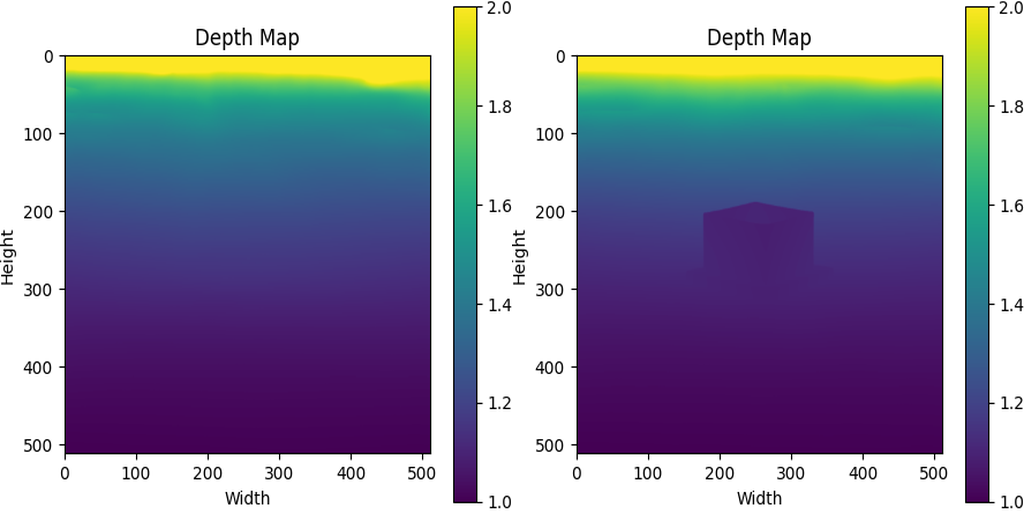

In [13]:
import io
def vis_depth_map(depth_map, vmin=None, vmax=None, save_clean=False):
    depth_map = np.squeeze(depth_map)
    if depth_map.ndim != 2:
        raise ValueError("Depth map after squeezing must be 2D.")

    dpi = 100  # Adjust this value if necessary
    figsize = (depth_map.shape[1] / dpi, depth_map.shape[0] / dpi)  # Width, Height in inches

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    cax = ax.imshow(depth_map, cmap='viridis', vmin=vmin, vmax=vmax)

    if not save_clean:
        # Standard save with labels and color bar
        cbar = fig.colorbar(cax)
        ax.set_title("Depth Map")
        ax.set_xlabel("Width")
        ax.set_ylabel("Height")
    else:
        # Clean save without labels, color bar, or axis
        plt.axis('off')
        ax.set_aspect('equal', adjustable='box')

    # Save to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
    buf.seek(0)
    img = Image.open(buf)
    img = img.convert('RGB')  # Convert to RGB
    img = img.resize((depth_map.shape[1], depth_map.shape[0]), Image.Resampling.LANCZOS)  # Resize to original dimensions
    # img.save(file_name, format='png')
    buf.close()
    plt.close()
    return img
def remap_depth(depth_map, remap_depth, valid_mask=None, percentile_clip=95):
    '''
    把深度图中“有效深度值”先做截断，再归一化，最后重新映射到一个新的深度范围里。
    '''
    depth_map = depth_map.clone()
    
    valid_depths = depth_map[valid_mask]
    
    clip_max = torch.quantile(valid_depths, percentile_clip / 100.0)
    
    min_val = valid_depths.min()
    max_val = clip_max
    
    if max_val - min_val < 1e-8:
        return depth_map
    
    normalized = torch.zeros_like(depth_map)
    clipped_depths = torch.clamp(depth_map[valid_mask], max=clip_max)
    normalized[valid_mask] = (clipped_depths - min_val) / (max_val - min_val)
    
    remapped = normalized * (remap_depth[1] - remap_depth[0]) + remap_depth[0]
    
    remapped[~valid_mask] = torch.max(remapped[valid_mask])
    
    return remapped
input_image = ToTensor()(input_image_pil).to(device)
with torch.no_grad():
    depth_inpainted = moge_model.infer(inpainted_image, fov_x=fx_deg)['depth']# 背景深度
    depth_input = moge_model.infer(input_image, fov_x=fx_deg)['depth'] # 原图深度
    mask_noninf_inpainted = ~torch.isinf(depth_inpainted)
    mask_noninf_input = ~torch.isinf(depth_input)
    # 把无穷大的深度值，替换成当前有效深度里的最大值。这样后面做点云反投影时不会炸。
    if mask_noninf_inpainted.any():
        max_val_inpainted = depth_inpainted[mask_noninf_inpainted].max()
        depth_inpainted = depth_inpainted.clone()
        depth_inpainted[~mask_noninf_inpainted] = max_val_inpainted
    if mask_noninf_input.any():
        max_val_input = depth_input[mask_noninf_input].max()
        depth_input = depth_input.clone()
        depth_input[~mask_noninf_input] = max_val_input
    if 'remap_depth' in config:
        depth_inpainted = remap_depth(depth_inpainted, config['remap_depth'], mask_noninf_inpainted)
        depth_input = remap_depth(depth_input, config['remap_depth'], mask_noninf_input)

grid_pil(
    [
vis_depth_map(depth_inpainted.cpu().numpy()),
vis_depth_map(depth_input.cpu().numpy())
    ]
)



In [14]:
from pytorch3d.renderer import (
    PointsRenderer, PointsRasterizer, PointsRasterizationSettings, AlphaCompositor,
    MeshRenderer, MeshRasterizer, RasterizationSettings, SoftPhongShader,
    PerspectiveCameras, BlendParams, PointLights, TexturesVertex, mesh, HardFlatShader, Textures, NormWeightedCompositor
)
@torch.no_grad()
def get_camera_at_origin(device,init_focal_length ):
    K = torch.zeros((1, 4, 4), device= device)
    K[0, 0, 0] =  init_focal_length
    K[0, 1, 1] =  init_focal_length
    K[0, 0, 2] = 256
    K[0, 1, 2] = 256
    K[0, 3, 2] = 1
    K[0, 2, 3] = 1
    R = torch.eye(3, device= device).unsqueeze(0)
    T = torch.zeros((1, 3), device= device)
    camera = PerspectiveCameras(
        K=K, R=R, T=T, in_ndc=False, image_size=((512, 512),), device= device
    )
    return camera
init_focal_length = fx_pixels
current_camera = get_camera_at_origin(
    device=device,
    init_focal_length = init_focal_length
)

In [15]:
from kornia.geometry import PinholeCamera
from einops import rearrange
def convert_pytorch3d_kornia( camera, focal_length, size=512, update_intrinsics_parameters=None, new_size=512):
    transform_matrix_pt3d = camera.get_world_to_view_transform().get_matrix()[0]
    transform_matrix_w2c_pt3d = transform_matrix_pt3d.transpose(0, 1)

    pt3d_to_kornia = torch.diag(torch.tensor([-1.0, -1, 1, 1], device=camera.device))
    transform_matrix_w2c_kornia = pt3d_to_kornia @ transform_matrix_w2c_pt3d

    extrinsics = transform_matrix_w2c_kornia.unsqueeze(0)
    h = torch.tensor([size], device="cuda")
    w = torch.tensor([size], device="cuda")
    K = torch.eye(4)[None].to("cuda")
    K[0, 0, 2] = size // 2
    K[0, 1, 2] = size // 2
    K[0, 0, 0] = focal_length
    K[0, 1, 1] = focal_length
    if update_intrinsics_parameters is not None:
        u0, v0, w_crop, h_crop, p_left, p_right, p_up, p_down, scale = (
            update_intrinsics_parameters
        )
        new_cx = (K[0, 0, 2] - u0 + p_left) * scale
        new_cy = (K[0, 1, 2] - v0 + p_up) * scale
        new_fx = K[0, 0, 0] * scale
        new_fy = K[0, 1, 1] * scale
        K[0, 0, 2] = new_cx
        K[0, 1, 2] = new_cy
        K[0, 0, 0] = new_fx
        K[0, 1, 1] = new_fy
        new_h = torch.tensor([new_size], device="cuda")
        new_w = torch.tensor([new_size], device="cuda")
        return PinholeCamera(K, extrinsics, new_h, new_w)

    return PinholeCamera(K, extrinsics, h, w)

def depth2pc( depth_map, image, mask=None):
    target_size = (512, 512)
    # initialize the point cloud for background
    kf_camera =  convert_pytorch3d_kornia(current_camera, init_focal_length)
    point_depth = rearrange(depth_map.unsqueeze(0), "c h w -> (w h) c")
    # Set all inf values in point_depth to 6
    # point_depth[point_depth == float('inf')] = 6

    x = torch.arange( target_size[0]).float() + 0.5
    y = torch.arange( target_size[1]).float() + 0.5

    points_cloud = torch.stack(torch.meshgrid(x, y, indexing="ij"), -1)
    points_cloud = rearrange(points_cloud, "h w c -> (h w) c").to(device)

    unprojected_points = kf_camera.unproject(points_cloud, point_depth)
    points_colors = rearrange(image, "c h w -> (w h) c")

    if mask is not None:
        mask = rearrange(mask, "h w -> (w h)")
        unprojected_points = unprojected_points[mask]
        points_colors = points_colors[mask]

    return unprojected_points, points_colors

# 把“深度图 + 对应图像”反投影成 3D 点云。
bg_points, bg_points_colors = depth2pc(depth_inpainted, inpainted_image)
input_image_points, input_image_colors = depth2pc(depth_input, input_image)


In [16]:

  
import os

from torchvision import utils as torchvision_utils
from simulation.image23D.single_view_reconstructor import HardShader
from pytorch3d.structures import Pointclouds, Meshes
from simulation.utils import (
    soft_stitching,
    dilate_binary_mask,
    extract_foreground_depth_torch,
    save_point_cloud_as_ply,
    save_depth_map,
    save_mask_kps,
    remove_isolated_areas,
    render_mesh_with_occlusion_detection,
    create_occluded_submesh,
    # sample_mesh_surface,
    # match_color_style,
)
output_folder = "/home/gaoya/Code_Video/demo_my/output"
target_size = (512,512)
def kps_from_quants( mask, idx):

    if 'obj_kp' in   config:
        quant = torch.tensor(  config['obj_kp'][idx][0]).float().to(  device)
        per_quant = torch.tensor(  config['obj_kp'][idx][1]).float().to(  device)
    else:
        quant = torch.tensor([0.1, 0.9]).float().to(  device)
        per_quant = torch.tensor([0.2, 0.8]).float().to(  device)

    mask_h, mask_w = torch.where(mask != 0)
    mask_w_min, mask_w_max = mask_w.min(), mask_w.max()
    
    quant_index = quant * (mask_w_max - mask_w_min) + mask_w_min
    quant_index = quant_index.long()

    select_hs = []
    select_ws = []
    for id in range(quant_index.shape[0]):
        valid_h = torch.where(mask[:,quant_index[id]] != 0)[0]
        valid_h, _ = torch.sort(valid_h)

        for jd in range(per_quant.shape[0]):
            select_h = valid_h[(valid_h.shape[0] * per_quant[jd]).long()]
            select_hs.append(select_h)
            select_ws.append(quant_index[id])
    
    select_hs = torch.stack(select_hs, dim=0)
    select_ws = torch.stack(select_ws, dim=0)
    return select_hs, select_ws
def obj_kp_matching( mask, mesh_vertices, mesh_faces, idx):

    gt_kp_h, gt_kp_w =   kps_from_quants(mask, idx)
    if   config.get('debug', False):
        gt_kp_save_path = os.path.join(output_folder,    "gt_kps.png")
        save_mask_kps(mask, gt_kp_h, gt_kp_w, gt_kp_save_path)

    verts_min = mesh_vertices.min(dim=0)[0].unsqueeze(0).unsqueeze(0)
    verts_max = mesh_vertices.max(dim=0)[0].unsqueeze(0).unsqueeze(0)

    proxy_colors = ((mesh_vertices.clone() - verts_min) / (
        verts_max - verts_min
    )).squeeze(0)
    
    z_translation = torch.tensor([0, 0, 0.5], device=  device)
    mesh_vertices += z_translation

    def render_mesh(mesh_vertices, mesh_faces, mesh_colors):
        textures = Textures(verts_rgb=mesh_colors.unsqueeze(0))
        obj_mesh = Meshes(
            verts=[mesh_vertices],
            faces=[mesh_faces],
            textures=textures
        )
        obj_raster_settings = RasterizationSettings(
            image_size=  target_size,
            blur_radius=0.0,
            faces_per_pixel=1
        )

        obj_renderer = MeshRenderer(
            rasterizer=MeshRasterizer(cameras=  current_camera, raster_settings=obj_raster_settings),
            shader=HardShader(device=  device, cameras=  current_camera),
        )
        rendered_images = obj_renderer(obj_mesh)
        rendered_rgb = rendered_images[0, ..., :3]
        rendered_mask = rendered_images[0, ..., -1]
        rendered_mask = (rendered_mask > 0).float()
        rendered_rgb = rendered_rgb.permute(2, 0, 1).clamp(0, 1)

        return rendered_rgb, rendered_mask


    fg_render, fg_mask = render_mesh(mesh_vertices, mesh_faces, proxy_colors)
    if   config.get('debug', False):
        torchvision_utils.save_image(fg_render,    os.path.join(output_folder,"mesh_init_render_proxy_color.png" ) )

    mesh_kps_h, mesh_kps_w =   kps_from_quants(fg_mask, idx)
    if   config.get('debug', False):
        mesh_kps_save_path =os.path.join(output_folder, "mesh_kps.png")
        save_mask_kps(fg_mask, mesh_kps_h, mesh_kps_w, mesh_kps_save_path)
    
    input_unprojected_points = rearrange(
          input_image_points, "(w h) c -> c h w", h=  target_size[0], w=  target_size[1]
    )

    gt_kps = input_unprojected_points[:, gt_kp_h, gt_kp_w].permute(1, 0)
    mesh_kps = fg_render[:, mesh_kps_h, mesh_kps_w].permute(1, 0)
    mesh_kps = mesh_kps * (verts_max[0] - verts_min[0]) + verts_min[0]

    A = mesh_kps
    B = gt_kps.flatten().unsqueeze(-1)
    A_compact = torch.cat(
        [
            A.unsqueeze(-1),
            torch.eye(3)
            .unsqueeze(0)
            .repeat(mesh_kps.shape[0], 1, 1)
            .to(device=  device),
        ],
        dim=-1,
    )
    A_compact_final = torch.cat([i for i in A_compact], dim=0)

    solution = torch.linalg.lstsq(A_compact_final, B).solution
    scale = solution[0]
    translation = solution[1:, 0]
    mesh_vertices -= z_translation

    return scale, translation
idx=0

if 'obj_kp_matching' in config and config['obj_kp_matching']:
# 如果开启了 obj_kp_matching，就根据关键点匹配结果，对当前物体的 mesh 再做一次尺度 + 平移校正，让它和图像中的物体更对齐
    scale, translation =   obj_kp_matching(per_mask, torch.from_numpy(original_mesh.vertices).to(device).float(), torch.from_numpy(original_mesh.faces).to(device).long(), idx)
    simplified_mesh.vertices = simplified_mesh.vertices * scale.item() + translation.cpu().numpy()
    original_mesh.vertices = original_mesh.vertices * scale.item() + translation.cpu().numpy()

'''
# 从当前相机视角渲染 mesh，并做遮挡检测
per_mask_from_mesh：这个 mesh 从当前相机看过去时的 2D mask
depth_map：这个 mesh 从当前相机看过去时的深度图
occluded_vertices_mask：mesh 顶点里哪些是被遮挡的
'''
per_mask_from_mesh, depth_map, occluded_vertices_mask = render_mesh_with_occlusion_detection(torch.from_numpy(original_mesh.vertices).to( device).float(), torch.from_numpy(original_mesh.faces).to( device).long(), torch.from_numpy(original_mesh.visual.vertex_colors).to( device).float()[:,:3]/255.0,  current_camera)
occluded_submesh_vertices, occluded_submesh_faces, occluded_submesh_colors = create_occluded_submesh(torch.from_numpy(original_mesh.vertices).to( device).float(), torch.from_numpy(original_mesh.faces).to( device).long(), torch.from_numpy(original_mesh.visual.vertex_colors).to( device).float()[:,:3]/255.0, occluded_vertices_mask)
per_points, per_colors = depth2pc(depth_map, input_image, per_mask_from_mesh)


#### 本地端口可视化

In [17]:
import os
import trimesh
import gradio as gr
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import os
import numpy as np
import torch
import trimesh
import matplotlib.pyplot as plt
from PIL import Image

def save_mask_png(mask, path, title=None):
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()
    mask = mask.astype(np.float32)
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask[..., 0]

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()

def save_depth_png(depth, path, title=None):
    if torch.is_tensor(depth):
        depth = depth.detach().cpu().numpy()
    depth = depth.astype(np.float32)

    valid = np.isfinite(depth)
    if valid.any():
        vmin = np.min(depth[valid])
        vmax = np.percentile(depth[valid], 95)
        depth_vis = depth.copy()
        depth_vis[~valid] = vmax
    else:
        vmin, vmax = 0.0, 1.0
        depth_vis = np.zeros_like(depth)

    plt.figure(figsize=(6, 6))
    plt.imshow(depth_vis, cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar()
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()

def save_mesh_any(mesh, path_obj, path_glb=None):
    mesh.export(path_obj)
    if path_glb is not None:
        mesh.export(path_glb)

def save_pointcloud_ply(points, colors, path):
    if torch.is_tensor(points):
        points = points.detach().cpu().numpy()
    if torch.is_tensor(colors):
        colors = colors.detach().cpu().numpy()

    if colors.max() <= 1.0:
        colors = (colors * 255).clip(0, 255).astype(np.uint8)
    else:
        colors = colors.astype(np.uint8)

    pc = trimesh.points.PointCloud(vertices=points, colors=colors)
    pc.export(path)
def show_mesh_matplotlib(mesh, title="mesh", elev=20, azim=45):
    verts = mesh.vertices
    faces = mesh.faces

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    tri = verts[faces]
    collection = Poly3DCollection(
        tri,
        alpha=0.9,
        linewidths=0.05
    )

    if hasattr(mesh.visual, "vertex_colors") and mesh.visual.vertex_colors is not None:
        colors = mesh.visual.vertex_colors[:, :3] / 255.0
        face_colors = colors[faces].mean(axis=1)
        collection.set_facecolor(face_colors)
    else:
        collection.set_facecolor((0.7, 0.7, 0.8))

    ax.add_collection3d(collection)

    mins = verts.min(axis=0)
    maxs = verts.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)

    ax.view_init(elev=elev, azim=azim)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
def show_pointcloud(points, colors=None, title="pointcloud"):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection='3d')

    pts = points.cpu().numpy() if hasattr(points, "cpu") else points
    if colors is not None:
        cols = colors.cpu().numpy() if hasattr(colors, "cpu") else colors
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], c=cols, s=0.5)
    else:
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=0.5)

    mins = pts.min(axis=0)
    maxs = pts.max(axis=0)
    center = (mins + maxs) / 2
    radius = (maxs - mins).max() / 2

    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def launch_mesh_viewer_from_results(
    original_mesh,
    simplified_mesh,
    output_dir="/home/gaoya/Code_Video/RealWonder-main/debug_my/mesh_vis",
    port=7860,
    shift_simplified=False,
    share  = True,
):
    os.makedirs(output_dir, exist_ok=True)

    # 1) 分别导出单独文件
    original_glb = os.path.join(output_dir, "original_mesh.glb")
    simplified_glb = os.path.join(output_dir, "simplified_mesh.glb")
    original_mesh.export(original_glb)
    simplified_mesh.export(simplified_glb)

    # 2) 再导出一个合并场景，方便同屏对比
    scene = trimesh.Scene()

    orig = original_mesh.copy()
    simp = simplified_mesh.copy()

    # 上色，便于区分
    if hasattr(orig.visual, "vertex_colors"):
        orig.visual.vertex_colors = np.tile(
            np.array([[255, 0, 0, 180]], dtype=np.uint8),
            (len(orig.vertices), 1)
        )
    if hasattr(simp.visual, "vertex_colors"):
        simp.visual.vertex_colors = np.tile(
            np.array([[0, 0, 255, 180]], dtype=np.uint8),
            (len(simp.vertices), 1)
        )

    # 可选：把 simplified 平移一点，避免完全重叠
    if shift_simplified:
        bbox_min = orig.vertices.min(axis=0)
        bbox_max = orig.vertices.max(axis=0)
        size = bbox_max - bbox_min
        shift = np.array([max(size[0], 1e-3) * 1.5, 0.0, 0.0])
        simp.vertices = simp.vertices + shift

    scene.add_geometry(orig, node_name="original_mesh")
    scene.add_geometry(simp, node_name="simplified_mesh")

    combined_glb = os.path.join(output_dir, "combined_meshes.glb")
    scene.export(combined_glb)

    # 3) 启动 Gradio
    with gr.Blocks() as demo:
        gr.Markdown("# Mesh 交互可视化")
        gr.Markdown("红色：original_mesh；蓝色：simplified_mesh")

        with gr.Tab("Combined"):
            gr.Model3D(value=combined_glb, label="Combined Scene", height=700)

        with gr.Tab("Original"):
            gr.Model3D(value=original_glb, label="Original Mesh", height=700)

        with gr.Tab("Simplified"):
            gr.Model3D(value=simplified_glb, label="Simplified Mesh", height=700)

    demo.launch(
        server_name="127.0.0.1",   # 只监听本机，配合 SSH 转发最稳
        server_port=port,
        share=share,
        inbrowser=False,
    )

    return demo, {
        "original_glb": original_glb,
        "simplified_glb": simplified_glb,
        "combined_glb": combined_glb,
    }



In [18]:
debug_dir = os.path.join(config["output_folder"], "step_debug")
os.makedirs(debug_dir, exist_ok=True)

In [19]:
import os
import json
import numpy as np
import torch
import trimesh
import gradio as gr
import plotly.graph_objects as go
import matplotlib.pyplot as plt

# =========================
# 基础保存函数
# =========================

def save_mask_png(mask, path, title=None):
    if torch.is_tensor(mask):
        mask = mask.detach().cpu().numpy()
    mask = np.asarray(mask)
    if mask.ndim == 3 and mask.shape[-1] == 1:
        mask = mask[..., 0]

    plt.figure(figsize=(6, 6))
    plt.imshow(mask, cmap="gray")
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()


def save_depth_png(depth, path, title=None):
    if torch.is_tensor(depth):
        depth = depth.detach().cpu().numpy()
    depth = np.asarray(depth).astype(np.float32)

    valid = np.isfinite(depth)
    if valid.any():
        vmin = float(np.min(depth[valid]))
        vmax = float(np.percentile(depth[valid], 95))
        depth_vis = depth.copy()
        depth_vis[~valid] = vmax
    else:
        vmin, vmax = 0.0, 1.0
        depth_vis = np.zeros_like(depth)

    plt.figure(figsize=(6, 6))
    plt.imshow(depth_vis, cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar()
    if title:
        plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()


def save_mesh_any(mesh, path_obj, path_glb=None):
    mesh.export(path_obj)
    if path_glb is not None:
        mesh.export(path_glb)


def save_pointcloud_ply(points, colors, path):
    if torch.is_tensor(points):
        points = points.detach().cpu().numpy()
    if torch.is_tensor(colors):
        colors = colors.detach().cpu().numpy()

    points = np.asarray(points)
    colors = np.asarray(colors)

    if colors.max() <= 1.0:
        colors = (colors * 255).clip(0, 255).astype(np.uint8)
    else:
        colors = colors.astype(np.uint8)

    pc = trimesh.points.PointCloud(vertices=points, colors=colors)
    pc.export(path)


def pointcloud_to_plotly(points, colors=None, title="Point Cloud", max_points=50000, point_size=2):
    if torch.is_tensor(points):
        points = points.detach().cpu().numpy()
    if colors is not None and torch.is_tensor(colors):
        colors = colors.detach().cpu().numpy()

    points = np.asarray(points)
    if colors is not None:
        colors = np.asarray(colors)

    if len(points) > max_points:
        idx = np.random.choice(len(points), max_points, replace=False)
        points = points[idx]
        if colors is not None:
            colors = colors[idx]

    if colors is None:
        marker = dict(size=point_size, opacity=0.8)
    else:
        if colors.max() <= 1.0:
            colors = (colors * 255).clip(0, 255).astype(np.uint8)
        rgb_strings = [f"rgb({r},{g},{b})" for r, g, b in colors[:, :3]]
        marker = dict(size=point_size, color=rgb_strings, opacity=0.8)

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=points[:, 0],
                y=points[:, 1],
                z=points[:, 2],
                mode="markers",
                marker=marker,
            )
        ]
    )
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Z",
            aspectmode="data",
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        height=700,
    )
    return fig
class StepDebugger:
    """
    统一管理每个 step 的可视化产物、说明文本，并提供 Gradio 调试界面。
    """

    def __init__(self, debug_dir):
         debug_dir = debug_dir
        os.makedirs( debug_dir, exist_ok=True)
        self.steps = []

    def _register(self, step_key, title, description, artifacts):
        self.steps.append({
            "step_key": step_key,
            "title": title,
            "description": description,
            "artifacts": artifacts,
        })

    def add_mask(self, step_key, title, description, mask, filename):
        path = os.path.join(self.debug_dir, filename)
        save_mask_png(mask, path, title=title)
        self._register(
            step_key, title, description,
            [{"type": "image", "path": path, "label": title}]
        )

    def add_depth(self, step_key, title, description, depth, filename):
        path = os.path.join(self.debug_dir, filename)
        save_depth_png(depth, path, title=title)
        self._register(
            step_key, title, description,
            [{"type": "image", "path": path, "label": title}]
        )

    def add_mesh(self, step_key, title, description, mesh, filename_prefix):
        obj_path = os.path.join(self.debug_dir, f"{filename_prefix}.obj")
        glb_path = os.path.join(self.debug_dir, f"{filename_prefix}.glb")
        save_mesh_any(mesh, obj_path, glb_path)
        self._register(
            step_key, title, description,
            [{"type": "mesh", "path": glb_path, "label": title}]
        )

    def add_two_meshes(self, step_key, title, description, mesh_items):
        """
        mesh_items: list of (label, mesh, filename_prefix)
        """
        artifacts = []
        for label, mesh, filename_prefix in mesh_items:
            obj_path = os.path.join(self.debug_dir, f"{filename_prefix}.obj")
            glb_path = os.path.join(self.debug_dir, f"{filename_prefix}.glb")
            save_mesh_any(mesh, obj_path, glb_path)
            artifacts.append({"type": "mesh", "path": glb_path, "label": label})
        self._register(step_key, title, description, artifacts)

    def add_pointcloud(self, step_key, title, description, points, colors, filename_prefix):
        ply_path = os.path.join(self.debug_dir, f"{filename_prefix}.ply")
        save_pointcloud_ply(points, colors, ply_path)
        fig = pointcloud_to_plotly(points, colors, title=title)
        self._register(
            step_key, title, description,
            [
                {"type": "pointcloud_plot", "fig": fig, "label": title},
                {"type": "file", "path": ply_path, "label": f"{title} (PLY file)"}
            ]
        )

    def add_summary_text(self, step_key, title, description, text):
        txt_path = os.path.join(self.debug_dir, f"{step_key}.txt")
        with open(txt_path, "w", encoding="utf-8") as f:
            f.write(text)
        self._register(
            step_key, title, description,
            [{"type": "text", "text": text, "label": title}]
        )

    def launch(self, port=7864):
        with gr.Blocks() as demo:
            gr.Markdown("# 单物体 3D 重建调试面板")
            gr.Markdown("这个界面按步骤展示：输入 mask → mesh → 对齐 → 遮挡分析 → 点云融合 → 最终资产。")

            with gr.Tabs():
                for step in self.steps:
                    with gr.Tab(step["step_key"]):
                        gr.Markdown(f"## {step['title']}")
                        gr.Markdown(step["description"])

                        for item in step["artifacts"]:
                            if item["type"] == "image":
                                gr.Image(value=item["path"], label=item["label"], interactive=False)
                            elif item["type"] == "mesh":
                                gr.Model3D(value=item["path"], label=item["label"], height=700)
                            elif item["type"] == "pointcloud_plot":
                                gr.Plot(value=item["fig"], label=item["label"])
                            elif item["type"] == "text":
                                gr.Markdown(f"```text\n{item['text']}\n```")
                            elif item["type"] == "file":
                                gr.Markdown(f"文件已保存：`{item['path']}`")

        demo.launch(
            server_name="127.0.0.1",
            server_port=port,
            share=False,
            inbrowser=False,
            prevent_thread_lock=True,
            inline=False,   # 不在 Jupyter 里内嵌显示
            quiet=True,     # 少打印一些信息
            show_error=True,
        )
        return demo
    

if True:
    """
    对单个物体执行：
    1) 输入 mask 可视化
    2) mesh 生成
    3) 关键点匹配修正
    4) mesh 视角渲染与遮挡分析
    5) 可见表面点云构建
    6) 遮挡部分补全
    7) 最终 fg_mesh / fg_pc 构建
    8) 启动统一调试界面
    """

    # --------------------------------------
    # 初始化：创建本物体的资产列表与调试器
    # 作用：后面统一收集 mesh / point cloud / mask / depth 的可视化结果
    # --------------------------------------
    fg_meshes = []
    fg_pcs = []
    debugger = StepDebugger(debug_dir)

    # --------------------------------------
    # Step 1: 保存输入 mask
    # 作用：检查当前物体的 2D 分割区域是否正确
    # --------------------------------------
    debugger.add_mask(
        step_key=f"step1_mask_{idx:02d}",
        title=f"Step 1 - 输入 Mask（物体 {idx:02d}）",
        description="这是当前物体的输入分割 mask。白色区域表示当前物体在图像中的 2D 分割区域。",
        mask=per_mask,
        filename=f"step1_input_mask_{idx:02d}.png",
    )

    # --------------------------------------
    # Step 2: 调用 mesh_generator 生成 3D mesh
    # 作用：从“图像 + 当前物体 mask”恢复出该物体的 3D mesh
    # 输出：
    # - original_mesh: 更完整、细节更多的 mesh
    # - simplified_mesh: 面数更少、适合后续仿真的 mesh
    # - fx_pixels / fx_deg: 当前图像对应的相机参数
    # --------------------------------------
    original_mesh, simplified_mesh, fx_pixels, fx_deg, _ = mesh_generator(
        np.array(input_image_pil),
        per_mask.cpu().numpy(),
        mesh_resize_factor=config['mesh_resize_factor'],
        target_faces=config['target_faces']
    )

    debugger.add_two_meshes(
        step_key=f"step2_meshes_{idx:02d}",
        title=f"Step 2 - mesh_generator 输出（物体 {idx:02d}）",
        description=(
            "这一阶段展示 mesh_generator 的直接输出。\n\n"
            "- original_mesh：原始 mesh，细节更多\n"
            "- simplified_mesh：简化 mesh，后续更适合仿真\n"
            f"- fx_pixels={fx_pixels:.4f}, fx_deg={float(fx_deg):.4f}"
        ),
        mesh_items=[
            (f"original_mesh_{idx:02d}", original_mesh, f"step2_original_mesh_{idx:02d}"),
            (f"simplified_mesh_{idx:02d}", simplified_mesh, f"step2_simplified_mesh_{idx:02d}"),
        ]
    )

    summary_step2 = (
        f"[step2] fx_pixels={fx_pixels}, fx_deg={fx_deg}\n"
        f"[step2] original verts/faces: {original_mesh.vertices.shape}, {original_mesh.faces.shape}\n"
        f"[step2] simplified verts/faces: {simplified_mesh.vertices.shape}, {simplified_mesh.faces.shape}\n"
        f"[step2] original bbox min/max: {original_mesh.vertices.min(axis=0)}, {original_mesh.vertices.max(axis=0)}\n"
        f"[step2] simplified bbox min/max: {simplified_mesh.vertices.min(axis=0)}, {simplified_mesh.vertices.max(axis=0)}"
    )
    debugger.add_summary_text(
        step_key=f"step2_stats_{idx:02d}",
        title=f"Step 2 - mesh 基本统计（物体 {idx:02d}）",
        description="这里是 Step 2 生成出的两个 mesh 的顶点数、面数和包围盒范围。",
        text=summary_step2
    )

    # --------------------------------------
    # Step 3: 在关键点匹配前保存原始 mesh
    # 作用：后面和关键点匹配后的 mesh 做对比
    # --------------------------------------
    orig_before = original_mesh.copy()
    simp_before = simplified_mesh.copy()

    # --------------------------------------
    # Step 3: 执行关键点匹配（2D-3D 对齐修正）
    # 作用：根据 mask / mesh 信息求 scale 和 translation，
    #      让 mesh 在相机坐标里更贴合图像中的物体
    # --------------------------------------
    scale, translation = obj_kp_matching(
        per_mask,
        torch.from_numpy(original_mesh.vertices).to(device).float(),
        torch.from_numpy(original_mesh.faces).to(device).long(),
        idx
    )

    simplified_mesh.vertices = simplified_mesh.vertices * scale.item() + translation.cpu().numpy()
    original_mesh.vertices = original_mesh.vertices * scale.item() + translation.cpu().numpy()

    debugger.add_two_meshes(
        step_key=f"step3_kpm_{idx:02d}",
        title=f"Step 3 - 关键点匹配前后对比（物体 {idx:02d}）",
        description=(
            "这一步展示关键点匹配前后的 mesh。\n\n"
            "- before：匹配前\n"
            "- after：匹配后\n"
            f"- scale={scale.item():.6f}\n"
            f"- translation={translation.detach().cpu().numpy()}"
        ),
        mesh_items=[
            (f"before_kpm_original_{idx:02d}", orig_before, f"step3_before_kpm_original_{idx:02d}"),
            (f"after_kpm_original_{idx:02d}", original_mesh, f"step3_after_kpm_original_{idx:02d}"),
        ]
    )

    # --------------------------------------
    # Step 4: 从当前相机视角渲染 mesh 并做遮挡分析
    # 作用：
    # - per_mask_from_mesh：从 mesh 渲染出的 2D mask
    # - depth_map：从 mesh 渲染出的深度图
    # - occluded_vertices_mask：哪些顶点被遮挡
    # --------------------------------------
    per_mask_from_mesh, depth_map, occluded_vertices_mask = render_mesh_with_occlusion_detection(
        torch.from_numpy(original_mesh.vertices).to(device).float(),
        torch.from_numpy(original_mesh.faces).to(device).long(),
        torch.from_numpy(original_mesh.visual.vertex_colors).to(device).float()[:, :3] / 255.0,
        current_camera
    )

    debugger.add_mask(
        step_key=f"step4_mesh_mask_{idx:02d}",
        title=f"Step 4A - 从 mesh 渲染得到的 mask（物体 {idx:02d}）",
        description="这是 original_mesh 从当前相机视角渲染出来的 2D mask，用来检查 mesh 的投影轮廓是否合理。",
        mask=per_mask_from_mesh,
        filename=f"step4_mask_from_mesh_{idx:02d}.png",
    )

    debugger.add_depth(
        step_key=f"step4_depth_{idx:02d}",
        title=f"Step 4B - 从 mesh 渲染得到的深度图（物体 {idx:02d}）",
        description="这是 original_mesh 从当前相机视角渲染得到的深度图，可用于后续反投影点云。",
        depth=depth_map,
        filename=f"step4_depth_map_{idx:02d}.png",
    )

    if torch.is_tensor(occluded_vertices_mask):
        occ_ratio = occluded_vertices_mask.float().mean().item()
    else:
        occ_ratio = np.mean(occluded_vertices_mask.astype(np.float32))

    debugger.add_summary_text(
        step_key=f"step4_occlusion_stats_{idx:02d}",
        title=f"Step 4C - 遮挡统计（物体 {idx:02d}）",
        description="这里记录当前 mesh 中有多少比例的顶点被判定为遮挡。",
        text=f"[step4] occluded vertex ratio = {occ_ratio:.4f}"
    )

    # --------------------------------------
    # Step 5: 提取被遮挡的子 mesh
    # 作用：把 original_mesh 中被遮挡的部分单独拆出来
    # --------------------------------------
    occluded_submesh_vertices, occluded_submesh_faces, occluded_submesh_colors = create_occluded_submesh(
        torch.from_numpy(original_mesh.vertices).to(device).float(),
        torch.from_numpy(original_mesh.faces).to(device).long(),
        torch.from_numpy(original_mesh.visual.vertex_colors).to(device).float()[:, :3] / 255.0,
        occluded_vertices_mask
    )

    occluded_mesh = trimesh.Trimesh(
        vertices=occluded_submesh_vertices.detach().cpu().numpy(),
        faces=occluded_submesh_faces.detach().cpu().numpy(),
        vertex_colors=(occluded_submesh_colors.detach().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
    )

    debugger.add_mesh(
        step_key=f"step5_occluded_mesh_{idx:02d}",
        title=f"Step 5 - 被遮挡子 mesh（物体 {idx:02d}）",
        description="这一步把 original_mesh 中被遮挡的那部分单独提取出来，后面会与可见表面点云融合。",
        mesh=occluded_mesh,
        filename_prefix=f"step5_occluded_submesh_{idx:02d}"
    )

    debugger.add_summary_text(
        step_key=f"step5_stats_{idx:02d}",
        title=f"Step 5 - 被遮挡子 mesh 统计（物体 {idx:02d}）",
        description="这里是被遮挡子 mesh 的顶点数和面数。",
        text=f"[step5] occluded submesh verts/faces: {occluded_submesh_vertices.shape}, {occluded_submesh_faces.shape}"
    )

    # --------------------------------------
    # Step 6: 把可见深度图反投影成点云
    # 作用：从 depth_map + input_image + per_mask_from_mesh 得到当前视角下可见表面的点云
    # --------------------------------------
    per_points, per_colors = depth2pc(depth_map, input_image, per_mask_from_mesh)

    debugger.add_pointcloud(
        step_key=f"step6_visible_pc_{idx:02d}",
        title=f"Step 6 - 可见表面点云（物体 {idx:02d}）",
        description="这是由 depth_map 反投影得到的当前视角下可见表面点云，只包含前面能看到的那部分。",
        points=per_points,
        colors=per_colors,
        filename_prefix=f"step6_visible_points_{idx:02d}"
    )

    debugger.add_summary_text(
        step_key=f"step6_stats_{idx:02d}",
        title=f"Step 6 - 可见点云统计（物体 {idx:02d}）",
        description="这里记录可见点云的点数和颜色数组大小。",
        text=f"[step6] per_points: {per_points.shape}, per_colors: {per_colors.shape}"
    )

    # --------------------------------------
    # Step 7: 构造最终融合点云
    # 作用：
    # - 如果 use_rgb_frontside=True：前侧用真实可见表面点云，后侧补上遮挡子 mesh 顶点
    # - 否则直接使用 original_mesh 顶点作为点云
    # --------------------------------------
    if config.get('use_rgb_frontside', True):
        merged_per_points = torch.cat([per_points, occluded_submesh_vertices], dim=0)
        merged_per_colors = torch.cat([per_colors, occluded_submesh_colors], dim=0)
        merge_desc = (
            "当前配置 use_rgb_frontside=True。\n\n"
            "最终点云由两部分拼接而成：\n"
            "1. 前侧可见表面点云 per_points\n"
            "2. 后侧被遮挡部分的子 mesh 顶点 occluded_submesh_vertices"
        )
    else:
        merged_per_points = torch.from_numpy(original_mesh.vertices).to(device).float()
        merged_per_colors = torch.from_numpy(original_mesh.visual.vertex_colors).to(device).float()[:, :3] / 255.0
        merge_desc = (
            "当前配置 use_rgb_frontside=False。\n\n"
            "最终点云直接使用 original_mesh 的顶点和颜色。"
        )

    debugger.add_pointcloud(
        step_key=f"step7_merged_pc_{idx:02d}",
        title=f"Step 7 - 融合后的最终前景点云（物体 {idx:02d}）",
        description=merge_desc,
        points=merged_per_points,
        colors=merged_per_colors,
        filename_prefix=f"step7_merged_points_{idx:02d}"
    )

    debugger.add_summary_text(
        step_key=f"step7_stats_{idx:02d}",
        title=f"Step 7 - 融合点云统计（物体 {idx:02d}）",
        description="这里记录最终融合点云的点数。",
        text=f"[step7] merged_per_points: {merged_per_points.shape}"
    )

    # --------------------------------------
    # Step 8: 保存最终前景资产
    # 作用：
    # - fg_meshes：给后续仿真用的 mesh（simplified_mesh）
    # - fg_pcs：给后续渲染/更新用的点云（merged_per_points）
    # --------------------------------------
    fg_meshes.append(
        { 
            'vertices': torch.from_numpy(simplified_mesh.vertices).to(device).float(),
            'faces': torch.from_numpy(simplified_mesh.faces).to(device).long(),
            'colors': torch.from_numpy(simplified_mesh.visual.vertex_colors).to(device).float()[:, :3] / 255.0
        }
    )

    fg_pcs.append(
        {
            'points': merged_per_points,
            'colors': merged_per_colors
        }
    )

    fg_mesh_trimesh = trimesh.Trimesh(
        vertices=fg_meshes[-1]["vertices"].detach().cpu().numpy(),
        faces=fg_meshes[-1]["faces"].detach().cpu().numpy(),
        vertex_colors=(fg_meshes[-1]["colors"].detach().cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
    )

    debugger.add_mesh(
        step_key=f"step8_fg_mesh_{idx:02d}",
        title=f"Step 8A - 最终 fg_mesh（物体 {idx:02d}）",
        description="这是最终存入 fg_meshes 的 mesh，后续主要给物理仿真使用。",
        mesh=fg_mesh_trimesh,
        filename_prefix=f"step8_fg_mesh_{idx:02d}"
    )

    debugger.add_pointcloud(
        step_key=f"step8_fg_pc_{idx:02d}",
        title=f"Step 8B - 最终 fg_pc（物体 {idx:02d}）",
        description="这是最终存入 fg_pcs 的点云，后续主要用于随仿真更新并重新渲染。",
        points=fg_pcs[-1]["points"],
        colors=fg_pcs[-1]["colors"],
        filename_prefix=f"step8_fg_pc_{idx:02d}"
    )
fg_pcs_from_3d = fg_pcs
fg_meshes = fg_meshes

debug_dir = os.path.join(config["output_folder"], f"single_obj_debug_{idx:02d}")
os.makedirs(debug_dir, exist_ok=True)


port = 7869
debugger.launch(port=port)
# demo = result_dict["debugger"].launch(port=port)
print(f"Remote viewer running on 127.0.0.1:{port}")

/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:27: UserWarning: Glyph 36755 (\N{CJK UNIFIED 

[mesh_generator] intrinsics is None, fallback to default FOV=60 deg
mesh is not watertight, filling holes...
-0.195 1.785


/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 20174 (\N{CJK UNIFIED IDEOGRAPH-4ECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 28210 (\N{CJK UNIFIED IDEOGRAPH-6E32}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 26579 (\N{CJK UNIFIED IDEOGRAPH-67D3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:26: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2539738/647680583.py:27: UserWarning: Glyph 20174 (\N{CJK UNIFIED I

Remote viewer running on 127.0.0.1:7869


#### 得到最终用于仿真的前景物体mesh（fg_meshes）和3d点云（fg_pcs_from_3d）

### 准备 Genesis

In [ ]:
from simulation.utils import (
    pt3d_to_gs,
    gs_to_pt3d,
    save_gif_from_image_folder,
    save_video_from_pil,
    pose_to_transform_matrix,
)
ground_plane_normal = None
if ground_plane_normal is not None:
    ground_plane_normal = pt3d_to_gs(ground_plane_normal)
    if ground_plane_normal[2] < 0:
        ground_plane_normal = -ground_plane_normal

fg_pcs = []
for idx, per_obj_pc in enumerate(fg_pcs_from_3d):
    fg_pcs.append({
        'points': pt3d_to_gs(per_obj_pc['points'].clone()),
        'colors': pt3d_to_gs(per_obj_pc['colors'].clone()),
    })
for idx, per_obj_mesh in enumerate(fg_meshes):
    per_obj_mesh['vertices'] = pt3d_to_gs(per_obj_mesh['vertices'])



In [31]:
import genesis as gs
gs.init(
    seed=config['seed'],
    precision="32",
    backend=gs.gpu,
    logging_level="warning"
)

[I 03/12/26 04:11:47.291 2539738] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/genesis/__init__.py:39: UserWarning:

'torch<2.8.0' is not supported. Please upgrade pytorch manually: https://pytorch.org/get-started/locally/



[Genesis] [04:11:49] [WARNING] 'torch<2.8.0' is not supported. Please upgrade pytorch manually: https://pytorch.org/get-started/locally/


In [46]:
all_obj_info = []
all_obj_occupied_lower_bound = torch.tensor([float('inf'), float('inf'), float('inf')]).to(device)
all_obj_occupied_upper_bound = torch.tensor([float('-inf'), float('-inf'), float('-inf')]).to(device)
"""[9] For each foreground mesh:
- compute bbox stats (min/max/center/size)
- center vertices around its centroid (local frame)  mesh 居中
- export an OBJ for Genesis to load 导出成 obj 给 Genesis
- append metadata to all_obj_info
- update global occupied bounds
每个物体有自己的 mesh 文件路径
每个物体有自己的 bbox 信息
所有物体总体占据范围也统计出来了
"""
for idx, per_mesh_bounds in enumerate(fg_meshes):
    per_mesh_min = fg_meshes[idx]['vertices'].min(0).values
    per_mesh_max = fg_meshes[idx]['vertices'].max(0).values
    per_mesh_center = fg_meshes[idx]['vertices'].mean(0)
    per_mesh_size = per_mesh_max - per_mesh_min

    fg_meshes[idx]['vertices'] -= per_mesh_center
    # fg_pcs[idx]['points'] -= per_mesh_center
    per_obj_mesh_path = os.path.join(config['output_folder'], f'fg_mesh_{idx:02d}.obj')
    
    per_trimesh = trimesh.Trimesh(
        vertices=fg_meshes[idx]['vertices'].cpu().numpy(), 
        faces=fg_meshes[idx]['faces'].cpu().numpy(), 
        vertex_colors=fg_meshes[idx]['colors'].cpu().numpy()
    )
    
    per_trimesh.export(per_obj_mesh_path)

    all_obj_info.append({
        'min': per_mesh_min,
        'max': per_mesh_max,
        'center': per_mesh_center,
        'size': per_mesh_size,
        'mesh_path': per_obj_mesh_path,
        'vertices': fg_meshes[idx]['vertices'] + per_mesh_center,
    })
    
    '''更新全局包围盒'''
    all_obj_occupied_lower_bound = torch.minimum(all_obj_occupied_lower_bound, per_mesh_min)
    all_obj_occupied_upper_bound = torch.maximum(all_obj_occupied_upper_bound, per_mesh_max)




In [47]:
from simulation.case_simulation.case_handler import get_case_handler
import time
from simulation.utils import save_gif_from_image_folder

case_handler = get_case_handler(config['example_name'], config, all_obj_info, device)
case_handler.set_simulation_bounds(all_obj_occupied_lower_bound, all_obj_occupied_upper_bound)
simulation_lower_bound, simulation_upper_bound = case_handler.get_simulation_bounds()

if ground_plane_normal is not None:
    gravity_dir = ground_plane_normal.copy()
else:
    gravity_dir = np.array([0, 0, 1])

if 'mpm_gravity' in config:
    if isinstance(config['mpm_gravity'], (int, float)):
        mpm_gravity = tuple(config['mpm_gravity'] * np.array(gravity_dir))
    else:
        mpm_gravity = tuple(pt3d_to_gs(np.array(config['mpm_gravity'])))
else:
    mpm_gravity = None

if 'pbd_gravity' in config:
    if isinstance(config['pbd_gravity'], (int, float)):
        pbd_gravity = tuple(config['pbd_gravity'] * np.array(gravity_dir))
    else:
        pbd_gravity = tuple(pt3d_to_gs(np.array(config['pbd_gravity'])))
else:
    pbd_gravity = None

if 'gravity' in config:
    if isinstance(config['gravity'], (int, float)):
        gravity = tuple(config['gravity'] * np.array(gravity_dir))
    else:
        gravity = tuple(pt3d_to_gs(np.array(config['gravity'])))
else:
    gravity = tuple(-9.8 * np.array(gravity_dir))



In [48]:
dt = config["dt"]
substeps = config["substeps"]
simulated_frames_num = config["simulated_frames_num"]
frame_steps = config["frame_steps"]
simulation_steps = simulated_frames_num * frame_steps
material_type = config['material_type']

In [51]:

def map_pc_to_particles( obj_idx):
    sim_particles = torch.tensor(objs[obj_idx].init_particles).to(device)
    print(f"number of sim_particles: {sim_particles.shape[0]}")
    K = 256
    num_closest = 5 if 'closest_points_num' not in config else config['closest_points_num']
    point_chunks = torch.split(fg_pcs[obj_idx]['points'], K)
    closest_indices = []

    for chunk in tqdm(point_chunks):
        # Calculate pairwise distances between chunk and all particles
        # Using broadcasting to avoid memory issues
        # Shape: [K, 1, 3] - [1, N, 3] -> [K, N, 3] -> [K, N]
        distances = torch.norm(
            chunk.unsqueeze(1) - sim_particles.unsqueeze(0),
            dim=2
        )
        # Get top num_closest indices of closest particles for this chunk
        chunk_closest = torch.topk(distances, k=num_closest, dim=1, largest=False)[1]
        del distances
        closest_indices.append(chunk_closest)

    closest_indices = torch.cat(closest_indices)
    return closest_indices


def get_material_for_each( per_material_type):
    if per_material_type == "rigid":
        obj_material = gs.materials.Rigid(
            rho = 1000.0 if 'rigid_rho' not in config else config['rigid_rho'],
            friction = 5.0 if 'rigid_friction' not in config else config['rigid_friction'],
            coup_friction = 5 if 'rigid_coup_friction' not in config else config['rigid_coup_friction'],
            coup_softness = 0.002 if 'rigid_coup_softness' not in config else config['rigid_coup_softness'],
        )
        obj_vis_mode = "visual"
    elif per_material_type == 'pbd_liquid':
        obj_material = gs.materials.PBD.Liquid(
            rho = 1000.0 if 'pbd_rho' not in config else config['pbd_rho'],
            density_relaxation = 0.2 if 'pbd_density_relaxation' not in config else config['pbd_density_relaxation'],
            viscosity_relaxation = 0.1 if 'pbd_viscosity_relaxation' not in config else config['pbd_viscosity_relaxation'],
        )
        obj_vis_mode = "particle"

    elif per_material_type == "pbd_cloth":
        obj_material = gs.materials.PBD.Cloth(
            rho=4.0 if 'pbd_rho' not in config else config['pbd_rho'],
            static_friction=0.6 if 'pbd_static_friction' not in config else config['pbd_static_friction'],
            kinetic_friction=0.35 if 'pbd_kinetic_friction' not in config else config['pbd_kinetic_friction'],
            stretch_compliance=1e-7 if 'pbd_stretch_compliance' not in config else config['pbd_stretch_compliance'],
            bending_compliance=1e-5 if 'pbd_bending_compliance' not in config else config['pbd_bending_compliance'],
            stretch_relaxation=0.7 if 'pbd_stretch_relaxation' not in config else config['pbd_stretch_relaxation'],
            bending_relaxation=0.1 if 'pbd_bending_relaxation' not in config else config['pbd_bending_relaxation'],
            air_resistance=5e-3 if 'pbd_air_resistance' not in config else config['pbd_air_resistance'],

        )
        obj_vis_mode = "particle"
    elif per_material_type == "pbd_elastic":
        obj_material = gs.materials.PBD.Elastic(
            rho=300.0 if 'pbd_elastic_rho' not in config else config['pbd_elastic_rho'],
            static_friction=0.15 if 'pbd_elastic_static_friction' not in config else config['pbd_elastic_static_friction'],
            kinetic_friction=0.0 if 'pbd_elastic_kinetic_friction' not in config else config['pbd_elastic_kinetic_friction'],
            stretch_compliance=0.0 if 'pbd_elastic_stretch_compliance' not in config else config['pbd_elastic_stretch_compliance'],
            bending_compliance=0.0 if 'pbd_elastic_bending_compliance' not in config else config['pbd_elastic_bending_compliance'],
            volume_compliance=0.0 if 'pbd_elastic_volume_compliance' not in config else config['pbd_elastic_volume_compliance'],
            stretch_relaxation=0.1 if 'pbd_elastic_stretch_relaxation' not in config else config['pbd_elastic_stretch_relaxation'],
            bending_relaxation=0.1 if 'pbd_elastic_bending_relaxation' not in config else config['pbd_elastic_bending_relaxation'],
            volume_relaxation=0.1 if 'pbd_elastic_volume_relaxation' not in config else config['pbd_elastic_volume_relaxation'],
        )
        obj_vis_mode = "particle"
    elif per_material_type == "pbd_particle":
        obj_material = gs.materials.PBD.Particle()
        obj_vis_mode = "particle"
    elif per_material_type == "mpm_sand":
        obj_material = gs.materials.MPM.Sand(
            E = 1e6 if 'MPM_E' not in config else config['MPM_E'],
            nu = 0.2 if 'MPM_nu' not in config else config['MPM_nu'],
            rho = 1000.0 if 'MPM_rho' not in config else config['MPM_rho'],
            friction_angle = 45 if 'MPM_friction_angle' not in config else config['MPM_friction_angle'],
        )
        obj_vis_mode = "particle"
    elif per_material_type == "mpm_elastic":
        obj_material = gs.materials.MPM.Elastic(
            E = 1e6 if 'MPM_E' not in config else config['MPM_E'],
            nu = 0.2 if 'MPM_nu' not in config else config['MPM_nu'],
            rho = 1000.0 if 'MPM_rho' not in config else config['MPM_rho'],
        )
        obj_vis_mode = "particle"
    elif per_material_type == "mpm_liquid":
        obj_material = gs.materials.MPM.Liquid(
            E = 1e6 if 'MPM_E' not in config else config['MPM_E'],
            nu = 0.2 if 'MPM_nu' not in config else config['MPM_nu'],
            rho = 1000.0 if 'MPM_rho' not in config else config['MPM_rho'],
        )
        obj_vis_mode = "particle"
    elif per_material_type == "mpm_snow":
        obj_material = gs.materials.MPM.Snow(
            E = 1e6 if 'MPM_E' not in config else config['MPM_E'],
            nu = 0.2 if 'MPM_nu' not in config else config['MPM_nu'],
            rho = 1000.0 if 'MPM_rho' not in config else config['MPM_rho'],
        )
        obj_vis_mode = "particle"
    elif per_material_type == "mpm_elastic2plastic":
        obj_material = gs.materials.MPM.ElastoPlastic(
            E = 1e6 if 'MPM_E' not in config else config['MPM_E'],
            nu = 0.2 if 'MPM_nu' not in config else config['MPM_nu'],
            rho = 1000.0 if 'MPM_rho' not in config else config['MPM_rho'],
        )
        obj_vis_mode = "particle"
    else:
        raise NotImplementedError(f"The current material {per_material_type} is not supported for now")
    return obj_material, obj_vis_mode



scene = gs.Scene(
    sim_options = gs.options.SimOptions(
        dt=dt,
        gravity=gravity,
        substeps=substeps,
    ),
    show_viewer=False,
    vis_options = gs.options.VisOptions(
        show_world_frame = False,
        world_frame_size = 1.0,
        show_link_frame  = False,
        show_cameras     = False,
        plane_reflection = False,
        ambient_light    = (0.5, 0.5, 0.5),
        lights = [{
            'type': 'directional',
            'dir': (0, 0, 1),
            'color': (1.0, 1.0, 1.0),
            'intensity': 2.0
        }]
    ),
    renderer = gs.renderers.Rasterizer(),
    rigid_options=gs.options.RigidOptions(
        dt=dt,
        enable_collision=True,
        enable_self_collision=False,
        constraint_timeconst = 0.02,
    ),
    pbd_options = gs.options.PBDOptions(
        lower_bound = tuple(simulation_lower_bound),
        upper_bound = tuple(simulation_upper_bound),
        particle_size = 0.01 if 'particle_size' not in config else config['particle_size'],
        gravity = pbd_gravity,
    ),
    mpm_options = gs.options.MPMOptions(
        lower_bound = tuple(simulation_lower_bound),
        upper_bound = tuple(simulation_upper_bound),
        grid_density = 64 if 'MPM_grid_density' not in config else config['MPM_grid_density'],
        particle_size = 0.01 if 'particle_size' not in config else config['particle_size'],
        gravity = mpm_gravity,
    ),
    coupler_options=gs.options.LegacyCouplerOptions(
        rigid_pbd=True,
        rigid_mpm=True,
    )
)

# get materials for each object
obj_materials= []
obj_vis_modes = []
for idx, per_material_type in enumerate(material_type):
    obj_material, obj_vis_mode = get_material_for_each(per_material_type)
    obj_materials.append(obj_material)
    obj_vis_modes.append(obj_vis_mode)

objs = case_handler.add_entities_to_scene(scene, obj_materials, obj_vis_modes)

case_handler.before_scene_building(scene, objs, ground_plane_normal)

cam = scene.add_camera(
    res = (512, 512),
    pos = (0, -1, 0),
    lookat = (0, 1, 0),
    fov = config['fov_x_input'],
    GUI = False,
)
scene.build()

case_handler.after_scene_building()

# transform and binding
# original_transform_matrix = {}
closest_indices = {}
initial_transform_matrix = {}

for obj_idx, per_material_type in enumerate(material_type):
    if per_material_type == 'rigid':
        # for debug purpose
        # per_object_pos = objs[obj_idx].get_pos().cpu().numpy()
        # per_object_quat = objs[obj_idx].get_quat().cpu().numpy()
        # per_object_transform_matrix = torch.from_numpy(pose_to_transform_matrix(per_object_pos, per_object_quat)).to(device).float()
        # initial_transform_matrix[obj_idx] = per_object_transform_matrix
        objs[obj_idx].solver.update_vgeoms_render_T()
        rigid_T = objs[obj_idx].solver._vgeoms_render_T
        rigid_idx = objs[obj_idx].idx
        transform_matrix = torch.tensor(rigid_T[rigid_idx, 0]).to(device).float()
        initial_transform_matrix[obj_idx] = transform_matrix

    elif per_material_type in ['pbd_liquid', 'pbd_cloth', 'mpm_sand', 'mpm_liquid', 'mpm_elastic', 'mpm_snow', 'mpm_elastic2plastic', 'pbd_elastic', 'pbd_particle']:
        closest_indices[obj_idx] = map_pc_to_particles(obj_idx)
    else:
        raise NotImplementedError("The current material is not supported for now")

print("genesis scene construction finished")


genesis scene construction finished


In [42]:
simulation_lower_bound

array([inf, inf, inf], dtype=float32)